# Image Comparison with PyBox

This notebook demonstrates how to use the `ImageComparator` class from PyBox to compare two images using various methods.

## Prerequisites

Make sure you have PyBox installed. If not, you can install it using pip:

```bash
pip install pybox
```

For this example, we'll also need torchvision to load CIFAR-10 images:

```bash
pip install torchvision
```

In [21]:
# Import required libraries
from pybox.compare.image_comparator import ImageComparator
from torchvision.datasets import CIFAR10
from matplotlib import pyplot as plt

## Step 1: Load Images

We'll use the CIFAR-10 dataset to get some sample images. This dataset contains 60,000 32x32 color images in 10 classes, but we will only use 2.

In [22]:
# Download CIFAR-10 dataset (this may take a moment on first run)
dataset = CIFAR10(root='./data', download=True, train=False)

# Select two images to compare
image1 = dataset.data[2]
image2 = dataset.data[3]

print(f"Image 1 shape: {image1.shape}")
print(f"Image 2 shape: {image2.shape}")

Image 1 shape: (32, 32, 3)
Image 2 shape: (32, 32, 3)


## Step 2: Compare Images

Now we'll use the ImageComparator to compare the two images. The available methods are:
- 'MAE': Mean Absolute Error (L1 distance)
- 'MSE': Mean Squared Error (L2 distance squared)
- 'RMSE': Root Mean Square Error
- 'COSINE': Cosine distance
- 'GMD': Gradient Magnitude Difference

**May exist more methods**

We'll use 'GMD' for this example, which highlights structural differences.

In [23]:
# Create an instance of ImageComparator
comparator = ImageComparator()

# Compare the two images using GMD method
result = comparator.compare(image1, image2, method='GMD', cmap='GRAY')

print(f"Comparison result shape: {result.shape}")
print(f"Result dtype: {result.dtype}")

Comparison result shape: (32, 32, 1)
Result dtype: float64


## Step 3: Visualize Results

Let's display the original images and the comparison result side by side.

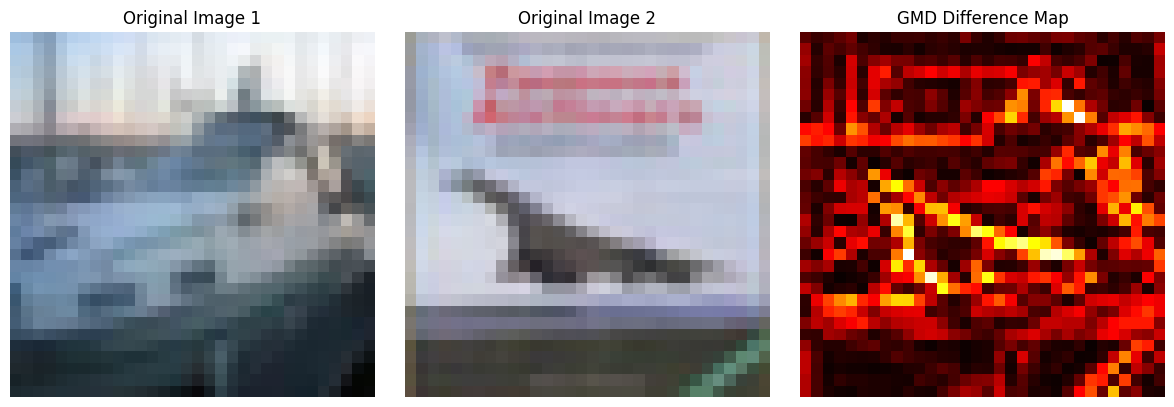

In [24]:
# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='hot')
plt.title('GMD Difference Map')
plt.axis('off')

plt.tight_layout()
plt.show()